In [50]:
# download libraries 
import numpy as np # vectorized math 
import pandas as pd # Neccessary for data manipulation
import sqlite3 # Database connection 
import matplotlib.pyplot as plt # visulization
import seaborn as sns # visualization

In [51]:
# connect to database 
db_path = r'C:\Users\dmiracju\Saftey-Risk-Analysis\database\Safety.db'
conn = sqlite3.connect(db_path)

# import dataset from database
process_path = pd.read_sql('Select * from feat_site_week_hours_path_risk', conn)

# view output
process_path 
    

,site,fiscal_year,week_sum,incidents_ytd,fclm_hours,process_path,incidents_weekly,avg_hours_per_path,avg_incident_per_path,fclm_hours_4wk_std,incident_4wk_std,incidents_per_1k_hours,hours_deviation,deviation_pct,process_path_rank,top_3_flag_path,incident_drop,incident_spike,hours_drop,hours_spike
0,teb3,2025,1,0,412.29,None,0,412.2900,0.0,0.000000,0.0,0.0,0.0000,312.29,1,1,0,0,0,0
1,teb3,2025,1,0,2184.62,admin/hr/it,0,2184.6200,0.0,0.000000,0.0,0.0,0.0000,2084.62,1,1,0,0,0,0
2,teb3,2025,1,0,142.55,box on demand,0,142.5500,0.0,0.000000,0.0,0.0,0.0000,42.55,1,1,0,0,0,0
3,teb3,2025,1,0,159.56,c-returns processed,0,159.5600,0.0,0.000000,0.0,0.0,0.0000,59.56,1,1,0,0,0,0
4,teb3,2025,1,0,104.94,c-returns support,0,104.9400,0.0,0.000000,0.0,0.0,0.0000,4.94,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2518,teb3,2025,52,0,47.02,v-returns pick,0,116.1750,0.0,43.428038,0.0,0.0,-69.1550,-52.98,4,0,0,0,1,0
2519,teb3,2025,52,0,0.02,v-returns rvr,0,0.1250,0.0,0.096307,0.0,0.0,-0.1050,-99.98,4,0,0,0,1,0
2520,teb3,2025,52,0,49.87,v-returns support,0,88.9625,0.0,22.931683,0.0,0.0,-39.0925,-50.13,4,0,0,0,1,0
2521,teb3,2025,52,0,13.64,whd grading,0,53.1650,0.0,24.113856,0.0,0.0,-39.5250,-86.36,4,0,0,0,1,0


In [53]:
#                                                   --- Explanatory Data Analysis (Where risk occurs ?) ---- 

# Goal: Evaluate which process paths generate frequent risk that happens over at TEB3. This phase will give us a better level of awareness on which areas we need to proactively focus on an coach. 

In [54]:
# create a new incidents weekly column with absolute values

process_path['incidents_weekly'] = (       
    process_path
    .sort_values(['week_sum', 'fiscal_year'])       
    .groupby('site')['incidents_ytd']               
    .diff()
).abs()

In [55]:
# coverage by path 

path_risk = process_path.groupby('process_path').agg(              # summarizing path statistics 
    total_incidents = ('incidents_weekly', 'sum'),     # sum of incdients
    total_hours = ('fclm_hours', 'sum'),               # sum of hours per path 
    avg_incident = ('incidents_weekly', 'mean'),        # average incident
    vol_incidents = ('incidents_weekly', 'std'),       # volatility in incidents per path
    vol_hours = ('fclm_hours', 'std'),                  # volatiltiy in hours per path 
).sort_values(['total_incidents'], ascending= False)

# results 
path_risk

,total_incidents,total_hours,avg_incident,vol_incidents,vol_hours
process_path,,,,,
pick,52.0,320213.80,1.000000,0.928841,1192.189664
stow to prime,40.0,147480.11,0.769231,0.899137,839.948114
ic-qa-cs,19.0,101362.78,0.365385,0.714797,316.453435
pack singles,16.0,111008.05,0.307692,0.642863,499.046255
stow to prime spt,15.0,12812.81,0.288462,0.571772,165.846120
pick support,12.0,31929.89,0.230769,0.546482,238.495077
each transfer in,11.0,34135.12,0.220000,0.581694,422.918516
each-receive,10.0,49199.31,0.192308,0.444507,216.068395
rsr support,8.0,63954.75,0.153846,0.364321,388.781290


In [71]:
# concetration of risk (pareto analysis)

# percenatge of incidents by each path
path_risk['pct_of_incidents'] = ( 
    path_risk['total_incidents'] /
    path_risk['total_incidents'].sum() 
)

# cumalative percentage 
path_risk['cum_pct'] = path_risk['pct_of_incidents'].cumsum()   # takes a running total down the table  (this only makes sense if path risk sorted by total incidents is descending first)

path_risk.head(10) # top 10 process path 


# top 10 paths account for 75% of incidents 

,total_incidents,total_hours,avg_incident,vol_incidents,vol_hours,pct_of_incidents,cum_pct
process_path,,,,,,,
pick,52.0,320213.80,1.000000,0.928841,1192.189664,0.205534,0.205534
stow to prime,40.0,147480.11,0.769231,0.899137,839.948114,0.158103,0.363636
ic-qa-cs,19.0,101362.78,0.365385,0.714797,316.453435,0.075099,0.438735
pack singles,16.0,111008.05,0.307692,0.642863,499.046255,0.063241,0.501976
stow to prime spt,15.0,12812.81,0.288462,0.571772,165.846120,0.059289,0.561265
pick support,12.0,31929.89,0.230769,0.546482,238.495077,0.047431,0.608696
each transfer in,11.0,34135.12,0.220000,0.581694,422.918516,0.043478,0.652174
each-receive,10.0,49199.31,0.192308,0.444507,216.068395,0.039526,0.691700
rsr support,8.0,63954.75,0.153846,0.364321,388.781290,0.031621,0.723320


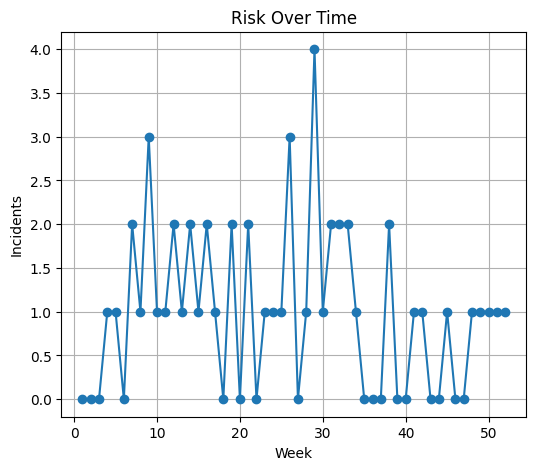

In [ ]:
# top risk paths over time (is this path consistently risk or episodic)

top_path = path_risk.index[0] # select path with highest overall risk

df_top = process_path[process_path['process_path'] == top_path] # keeps only rows belonging to top risk path (give me all the periods for the riskiest operational path)

# create plot 
plt.figure(figsize=(6,5)) # visulization size 
plt.plot(
    df_top['week_sum'],            # week (represents time)
    df_top['incidents_weekly'],    # incidents weekly
    marker = 'o'                   # plot dots at every end of a data point
)
plt.title('Risk Over Time')# title 
plt.xlabel('Week')         # x-axis label
plt.ylabel('Incidents')    # y-axis label   
plt.grid(True)             # makes plots more interpretable
plt.show()

# This path is consistenly risk and not driven by a few spikes in risk. 33 weeks of incidents out of 52. 


In [86]:
# rank stability (which process path were worst each period instead of overall )

# create a ranked process path within each period 
process_path['path_rank'] = (
    process_path.groupby(['fiscal_year', 'week_sum'])       # splits data into groups 
    ['incidents_weekly'].rank(ascending= False)             # within each period your ranking process path by incidents 
)

# use filter to output top 3 path 
process_path[process_path['path_rank'] <= 3].sort_values(['week_sum', 'path_rank']).head(20)





,site,fiscal_year,week_sum,incidents_ytd,fclm_hours,process_path,incidents_weekly,avg_hours_per_path,avg_incident_per_path,fclm_hours_4wk_std,...,incidents_per_1k_hours,hours_deviation,deviation_pct,process_path_rank,top_3_flag_path,incident_drop,incident_spike,hours_drop,hours_spike,path_rank
49,teb3,2025,2,1,2007.77,ic-qa-cs,1.0,1650.485000,0.500000,357.285000,...,0.498065,357.285000,1907.77,1,1,0,1,0,1,1.5
50,teb3,2025,2,0,414.26,None,1.0,413.275000,0.000000,0.985000,...,0.000000,0.985000,314.26,2,1,0,0,0,1,1.5
97,teb3,2025,3,1,1378.91,fluid load,1.0,1391.803333,0.333333,74.631526,...,0.725210,-12.893333,1278.91,1,1,0,1,1,0,2.5
98,teb3,2025,3,0,1973.69,ic-qa-cs,1.0,1758.220000,0.000000,329.113012,...,0.506665,215.470000,1873.69,2,1,1,0,0,1,2.5
99,teb3,2025,3,1,2998.84,admin/hr/it,1.0,2678.116667,0.333333,354.143587,...,0.333462,320.723333,2898.84,3,1,0,1,0,1,2.5
101,teb3,2025,3,0,515.37,None,1.0,447.306667,0.000000,48.134764,...,0.000000,68.063333,415.37,5,0,0,0,0,1,2.5
147,teb3,2025,4,1,1382.72,each-receive,1.0,1147.395000,0.250000,227.107487,...,0.723212,235.325000,1282.72,2,1,0,1,0,1,2.5
148,teb3,2025,4,0,3161.66,admin/hr/it,1.0,2799.002500,0.000000,371.353490,...,0.316290,362.657500,3061.66,3,1,1,0,0,1,2.5
150,teb3,2025,4,1,5063.97,pick,1.0,5061.195000,0.250000,114.643019,...,0.197474,2.775000,4963.97,5,0,0,1,0,1,2.5
151,teb3,2025,4,0,476.42,None,1.0,454.585000,0.000000,43.550419,...,0.000000,21.835000,376.42,6,0,0,0,0,1,2.5


0        NaN
1       24.5
2       24.5
3       24.5
4       24.5
        ... 
2518    26.5
2519    26.5
2520    26.5
2521    26.5
2522    26.5
Name: path_rank, Length: 2523, dtype: float64